
PHYSICAL SINGULARITY VISUALIZATION SUITE

[1/3] Continuous vs. Discrete Spiral Comparison...
  ✓ Saved: physical_singularity_comparison.png

[2/3] Base-10 Digit Boundary (The '9' Effect)...
  ✓ Saved: base9_boundary_effect.png

[3/3] 3D Spacetime Curvature (Continuous vs. Discrete)...
  ✓ Saved: 3d_spacetime_curvature.png

ALL VISUALIZATIONS COMPLETE!

📁 FILES GENERATED:
  • physical_singularity_comparison.png
  • base9_boundary_effect.png
  • 3d_spacetime_curvature.png

 KEY INSIGHTS VISUALIZED:
  1. Discrete spacetime AVOIDS the singularity (Planck cutoff)
  2. 1/0 is UNDEFINED, not INFINITE (bounded maximum)
  3. The digit '9' represents CYCLIC COMPLETION, not linear infinity
  4. No physical system grows unbounded (all have limits)

Foundation for Paper #2: 'The Physical Singularity'


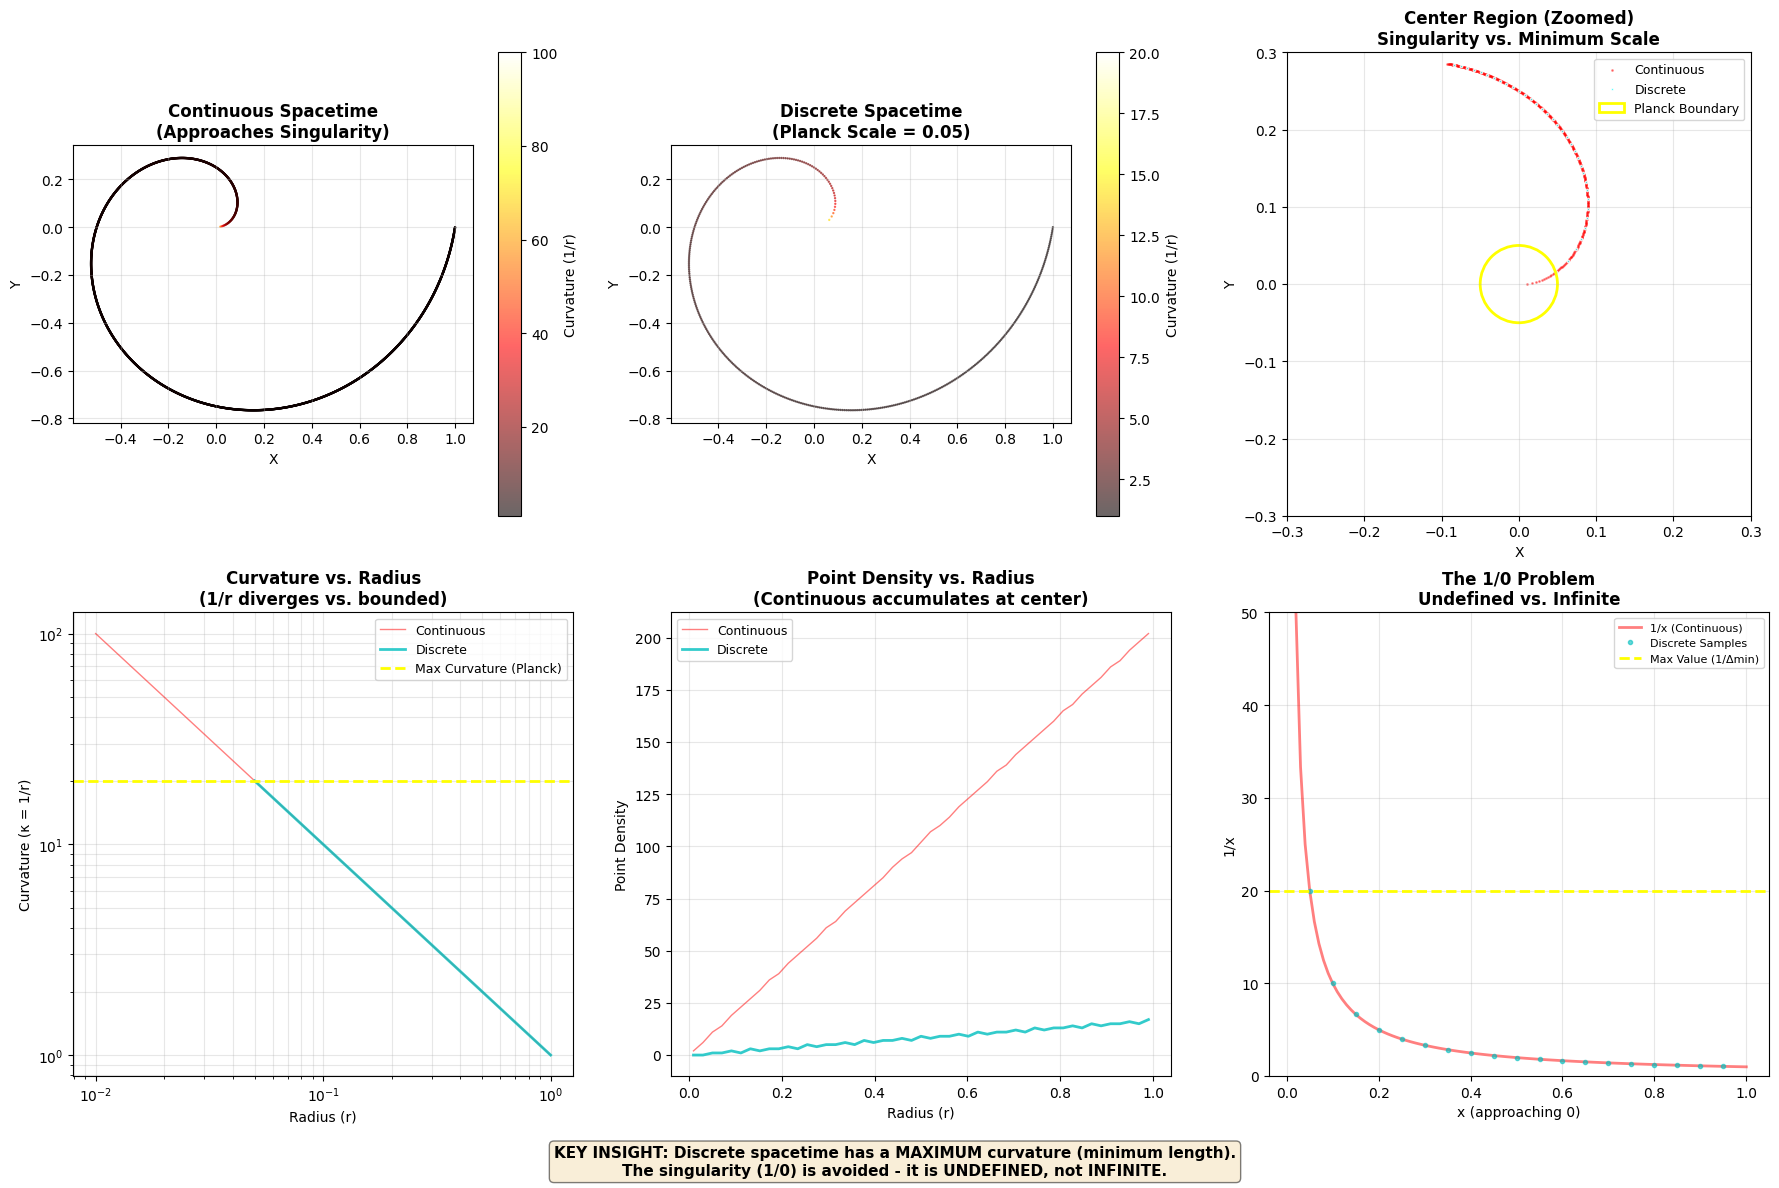

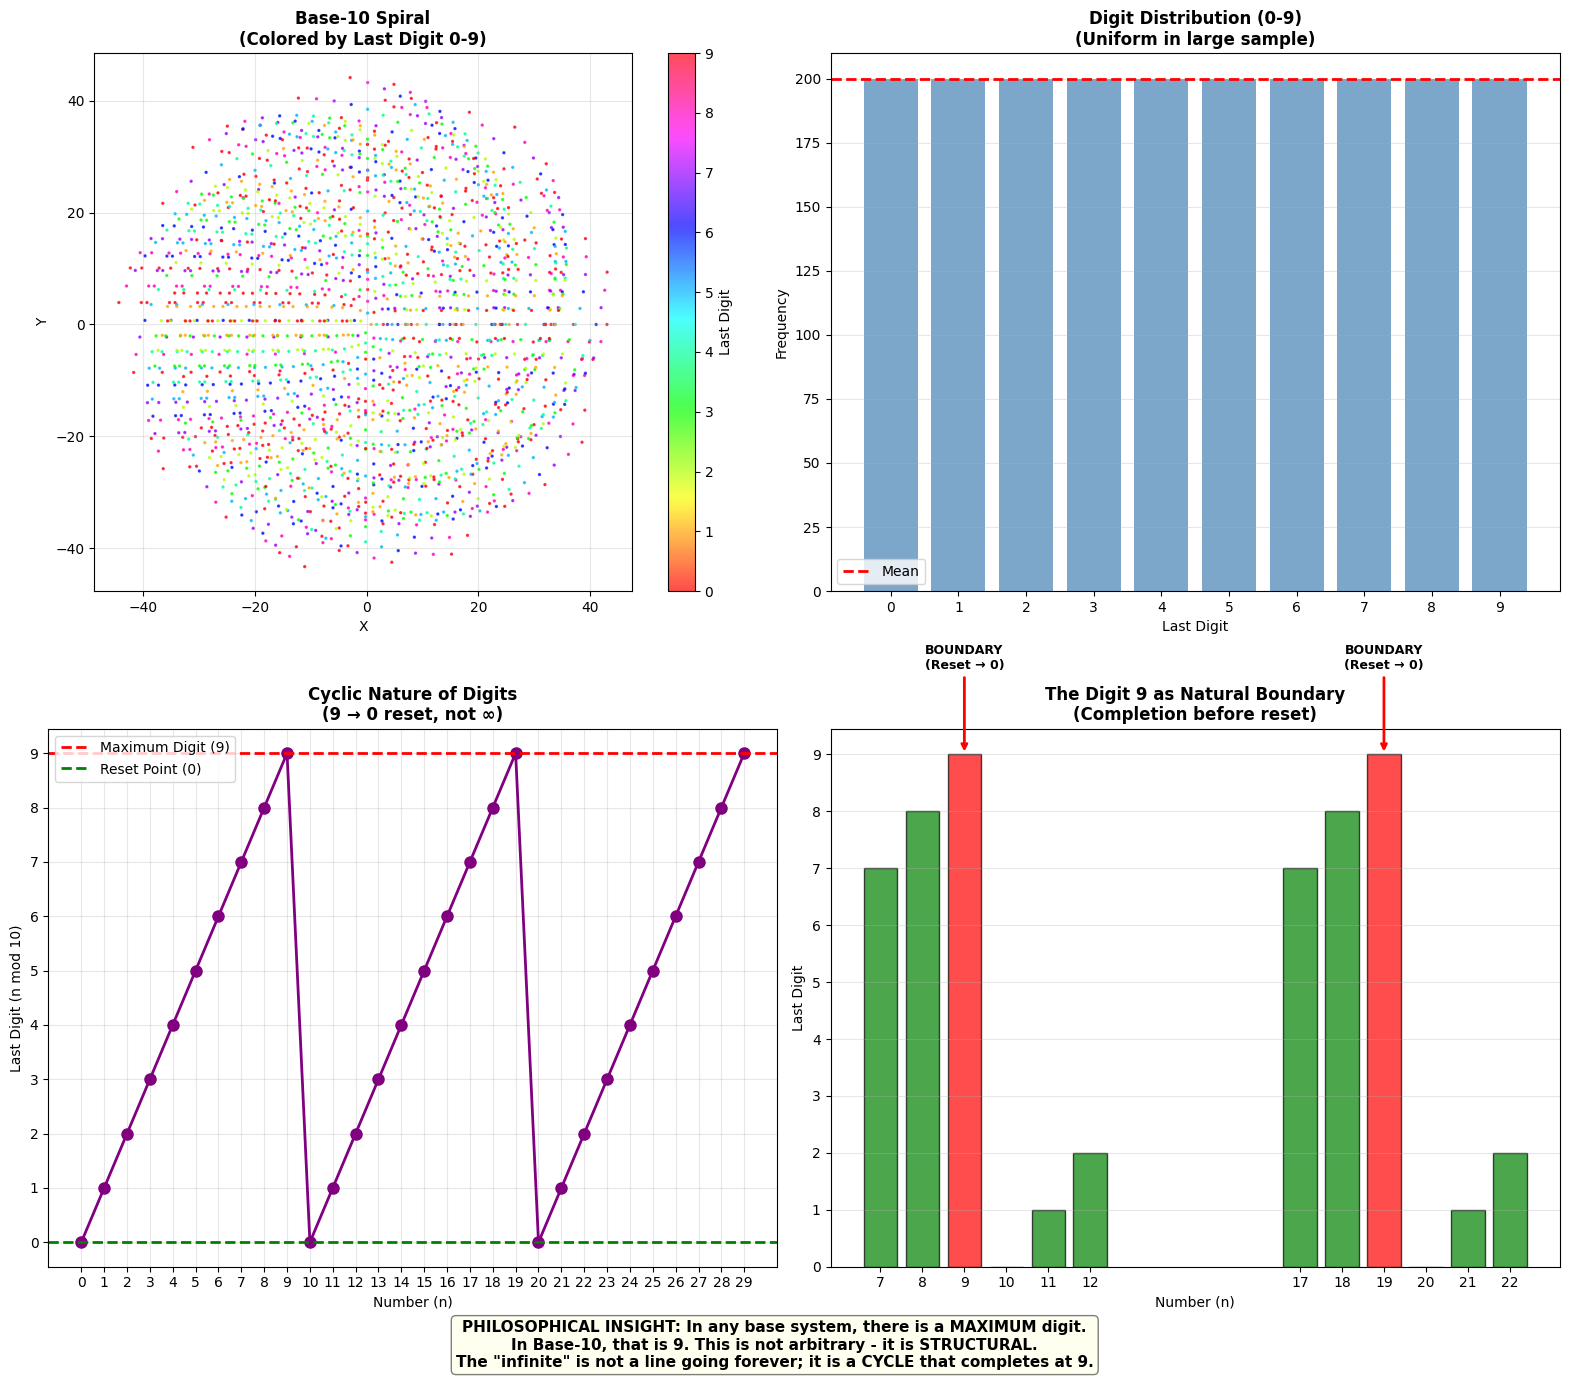

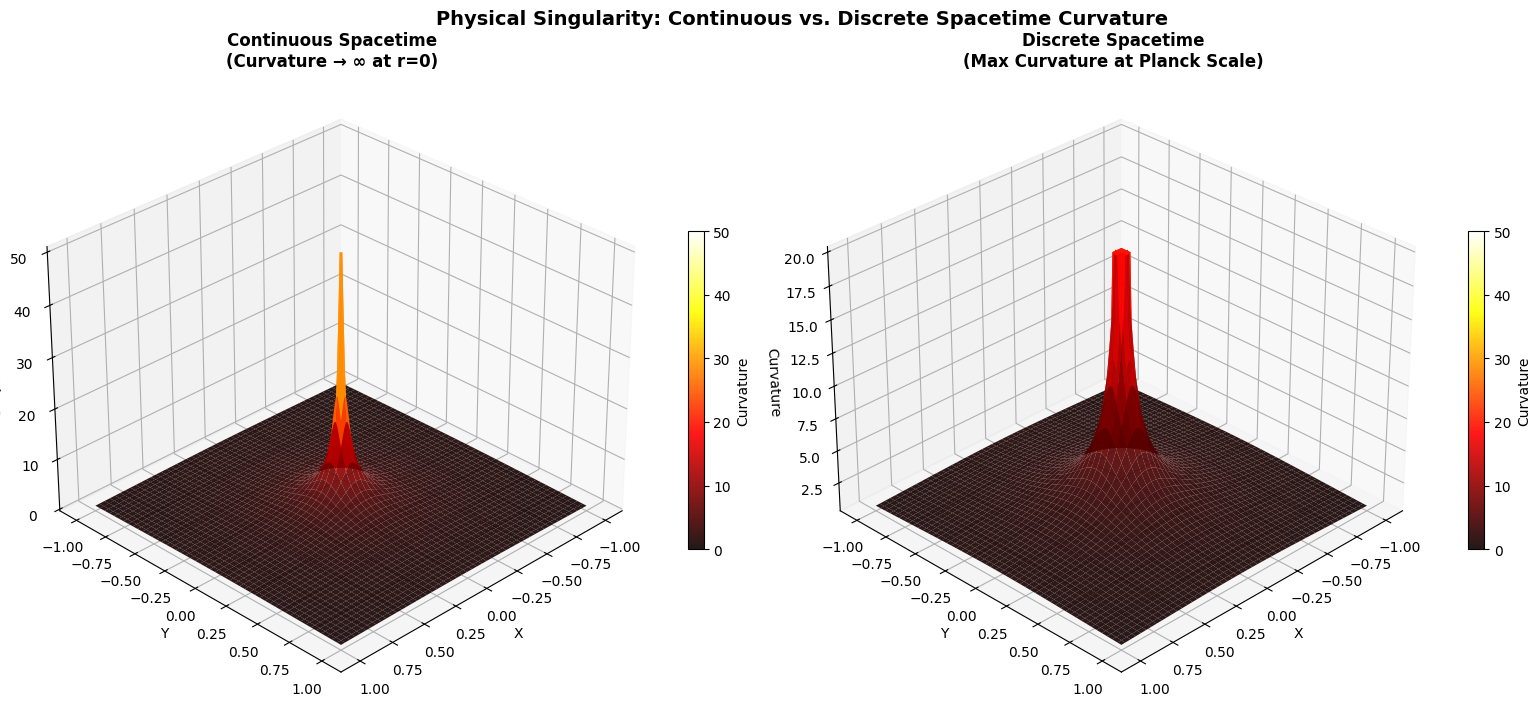

In [ ]:
"""
physical_singularity.py
========================
Visualizing how discrete spacetime (Planck scale) avoids singularities.

Demonstrates:
1. Continuous spiral → singularity at center (1/0 problem)
2. Discrete spiral → minimum radius (no singularity)
3. The "9" as a natural boundary in base-10 systems

Author: Néstor E. Ramos
For: "The Physical Singularity: Why Infinities Signal Model Boundaries"
"""

# =============================================================================
# IMPORTS
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import hsv, ScalarMappable
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# PHYSICAL CONSTANTS (for visualization scale)
# =============================================================================

# Planck length (meters) - the minimum meaningful length in physics
PLANCK_LENGTH = 1.616255e-35

# For visualization, we'll use a scaled "Planck pixel" size
VISUAL_PLANCK_SCALE = 0.05  # Normalized units

# =============================================================================
# SPIRAL GENERATORS
# =============================================================================

def generate_continuous_spiral(n_points=10000, n_min=0.001):
    """
    Generate a 'continuous' spiral that approaches the singularity.

    This represents the classical/continuum view of spacetime.
    As r → 0, curvature → infinity (the 1/0 problem).

    Parameters:
    -----------
    n_points : int
        Number of points in the spiral
    n_min : float
        Minimum n value (how close to center we get)

    Returns:
    --------
    x, y, r, curvature : arrays
        Coordinates, radius, and curvature at each point
    """
    n = np.linspace(n_min, 1, n_points)

    # Standard spiral: r = sqrt(n)
    r = np.sqrt(n)
    theta = np.sqrt(n) * 2 * np.pi  # Multiple rotations

    x = r * np.cos(theta)
    y = r * np.sin(theta)

    # Curvature κ = 1/r (diverges as r → 0)
    curvature = 1.0 / r

    return x, y, r, curvature, n


def generate_discrete_spiral(n_points=10000, planck_scale=VISUAL_PLANCK_SCALE):
    """
    Generate a 'discrete' spiral with Planck-scale cutoff.

    This represents the quantum/discrete view of spacetime.
    There is a minimum radius - no singularity possible.

    Parameters:
    -----------
    n_points : int
        Number of points in the spiral
    planck_scale : float
        Minimum step size (Planck length equivalent)

    Returns:
    --------
    x, y, r, curvature : arrays
        Coordinates, radius, and curvature at each point
    """
    # Discrete steps (like pixels)
    n = np.arange(planck_scale**2, 1 + planck_scale**2, planck_scale**2)
    n = n[:n_points]  # Limit to n_points

    # Spiral with discrete steps
    r = np.sqrt(n)
    theta = np.sqrt(n) * 2 * np.pi

    x = r * np.cos(theta)
    y = r * np.sin(theta)

    # Curvature is bounded (maximum at Planck scale)
    curvature = 1.0 / r
    max_curvature = 1.0 / np.min(r)  # Finite maximum!

    return x, y, r, curvature, n, max_curvature


def generate_base9_spiral(n_points=1000, base=10):
    """
    Generate a spiral showing the '9' boundary effect.

    In base-10, the digit 9 represents completion before reset.
    This creates a natural modular boundary.

    Parameters:
    -----------
    n_points : int
        Number of points
    base : int
        Numerical base (10 for decimal, 16 for hex, etc.)

    Returns:
    --------
    x, y, r, digit_value : arrays
        Coordinates, radius, and digit value at each point
    """
    max_digit = base - 1  # 9 for base-10, 15 for hex, etc.

    # Create numbers and extract last digit
    n = np.arange(1, n_points + 1)
    last_digit = n % base

    # Radius modulated by digit (shows cyclic pattern)
    r = np.sqrt(n) * (0.8 + 0.2 * last_digit / max_digit)
    theta = np.sqrt(n) * 2 * np.pi

    x = r * np.cos(theta)
    y = r * np.sin(theta)

    return x, y, r, last_digit, max_digit


# =============================================================================
# VISUALIZATION FUNCTIONS
# =============================================================================

def plot_continuous_vs_discrete():
    """
    Side-by-side comparison: Continuous vs. Discrete spiral.
    Shows how discreteness avoids the singularity.
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # Generate data
    x_cont, y_cont, r_cont, curv_cont, n_cont = generate_continuous_spiral(n_points=5000, n_min=0.0001)
    x_disc, y_disc, r_disc, curv_disc, n_disc, max_curv = generate_discrete_spiral(n_points=5000)

    # ===== ROW 1: SPIRAL VISUALIZATION =====

    # Left: Continuous (approaches singularity)
    ax1 = axes[0, 0]
    scatter1 = ax1.scatter(x_cont, y_cont, c=curv_cont, cmap='hot', s=0.5, alpha=0.6)
    ax1.set_title('Continuous Spacetime\n(Approaches Singularity)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('X'); ax1.set_ylabel('Y')
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)
    plt.colorbar(scatter1, ax=ax1, label='Curvature (1/r)')

    # Right: Discrete (Planck cutoff)
    ax2 = axes[0, 1]
    scatter2 = ax2.scatter(x_disc, y_disc, c=curv_disc, cmap='hot', s=0.5, alpha=0.6)
    ax2.set_title(f'Discrete Spacetime\n(Planck Scale = {VISUAL_PLANCK_SCALE})', fontsize=12, fontweight='bold')
    ax2.set_xlabel('X'); ax2.set_ylabel('Y')
    ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.3)
    plt.colorbar(scatter2, ax=ax2, label='Curvature (1/r)')

    # Center region comparison (zoom)
    ax3 = axes[0, 2]
    # Find points near center
    center_mask_cont = r_cont < 0.3
    center_mask_disc = r_disc < 0.3

    ax3.scatter(x_cont[center_mask_cont], y_cont[center_mask_cont],
                c='red', s=1, alpha=0.4, label='Continuous')
    ax3.scatter(x_disc[center_mask_disc], y_disc[center_mask_disc],
                c='cyan', s=3, alpha=0.8, label='Discrete', edgecolors='white')

    # Draw Planck scale circle
    circle = plt.Circle((0, 0), np.sqrt(VISUAL_PLANCK_SCALE**2),
                        color='yellow', fill=False, linewidth=2,
                        label='Planck Boundary')
    ax3.add_patch(circle)

    ax3.set_title('Center Region (Zoomed)\nSingularity vs. Minimum Scale',
                  fontsize=12, fontweight='bold')
    ax3.set_xlabel('X'); ax3.set_ylabel('Y')
    ax3.set_aspect('equal')
    ax3.legend(loc='upper right', fontsize=9)
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim([-0.3, 0.3])
    ax3.set_ylim([-0.3, 0.3])

    # ===== ROW 2: CURVATURE & DENSITY =====

    # Curvature comparison
    ax4 = axes[1, 0]
    ax4.plot(r_cont, curv_cont, 'r-', alpha=0.5, linewidth=1, label='Continuous')
    ax4.plot(r_disc, curv_disc, 'c-', alpha=0.8, linewidth=2, label='Discrete')
    ax4.axhline(y=max_curv, color='yellow', linestyle='--', linewidth=2,
                label=f'Max Curvature (Planck)')
    ax4.set_title('Curvature vs. Radius\n(1/r diverges vs. bounded)', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Radius (r)')
    ax4.set_ylabel('Curvature (κ = 1/r)')
    ax4.set_xscale('log')
    ax4.set_yscale('log')
    ax4.legend(fontsize=9)
    ax4.grid(True, alpha=0.3, which='both')

    # Density comparison
    ax5 = axes[1, 1]

    # Calculate point density in radial bins
    bins = np.linspace(0, 1, 50)
    density_cont, _ = np.histogram(r_cont, bins=bins)
    density_disc, _ = np.histogram(r_disc, bins=bins)

    bin_centers = (bins[:-1] + bins[1:]) / 2

    ax5.plot(bin_centers, density_cont, 'r-', alpha=0.5, linewidth=1, label='Continuous')
    ax5.plot(bin_centers, density_disc, 'c-', alpha=0.8, linewidth=2, label='Discrete')

    ax5.set_title('Point Density vs. Radius\n(Continuous accumulates at center)', fontsize=12, fontweight='bold')
    ax5.set_xlabel('Radius (r)')
    ax5.set_ylabel('Point Density')
    ax5.legend(fontsize=9)
    ax5.grid(True, alpha=0.3)

    # The "1/0" visualization
    ax6 = axes[1, 2]

    # Show 1/x function
    x_small = np.linspace(0.01, 1, 100)
    y_small = 1.0 / x_small

    ax6.plot(x_small, y_small, 'r-', alpha=0.5, linewidth=2, label='1/x (Continuous)')

    # Show discrete version
    x_disc_func = np.arange(VISUAL_PLANCK_SCALE, 1, VISUAL_PLANCK_SCALE)
    y_disc_func = 1.0 / x_disc_func

    ax6.plot(x_disc_func, y_disc_func, 'co', alpha=0.6, markersize=3, label='Discrete Samples')
    ax6.axhline(y=1/VISUAL_PLANCK_SCALE, color='yellow', linestyle='--', linewidth=2,
                label=f'Max Value (1/Δmin)')

    ax6.set_title('The 1/0 Problem\nUndefined vs. Infinite', fontsize=12, fontweight='bold')
    ax6.set_xlabel('x (approaching 0)')
    ax6.set_ylabel('1/x')
    ax6.set_ylim([0, 50])
    ax6.legend(fontsize=8)
    ax6.grid(True, alpha=0.3)

    # Add text annotation
    fig.text(0.5, 0.02,
             'KEY INSIGHT: Discrete spacetime has a MAXIMUM curvature (minimum length).\n'
             'The singularity (1/0) is avoided - it is UNDEFINED, not INFINITE.',
             ha='center', fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    return fig


def plot_base9_boundary():
    """
    Show how the digit '9' creates a natural boundary in base-10 systems.
    This demonstrates cyclic completion vs. linear infinity.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))

    # Generate base-10 spiral
    x, y, r, digits, max_digit = generate_base9_spiral(n_points=2000, base=10)

    # ===== LEFT: Full spiral with digit coloring =====
    ax1 = axes[0, 0]
    scatter1 = ax1.scatter(x, y, c=digits, cmap='hsv', s=2, alpha=0.7,
                           vmin=0, vmax=max_digit)
    ax1.set_title('Base-10 Spiral\n(Colored by Last Digit 0-9)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('X'); ax1.set_ylabel('Y')
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)
    cbar1 = plt.colorbar(scatter1, ax=ax1, label='Last Digit')
    cbar1.set_ticks(np.arange(0, max_digit+1, 1))

    # ===== RIGHT: Digit distribution =====
    ax2 = axes[0, 1]
    digit_counts = np.bincount(digits, minlength=10)
    ax2.bar(np.arange(10), digit_counts, color='steelblue', alpha=0.7)
    ax2.axhline(y=np.mean(digit_counts), color='red', linestyle='--',
                linewidth=2, label='Mean')
    ax2.set_title('Digit Distribution (0-9)\n(Uniform in large sample)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Last Digit')
    ax2.set_ylabel('Frequency')
    ax2.set_xticks(np.arange(10))
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

    # ===== BOTTOM LEFT: Cyclic nature (modular arithmetic) =====
    ax3 = axes[1, 0]

    # Show the cycle: 0,1,2,...,9,0,1,2,...
    n_cycle = np.arange(0, 30)
    digit_cycle = n_cycle % 10

    ax3.plot(n_cycle, digit_cycle, 'o-', linewidth=2, markersize=8, color='purple')
    ax3.axhline(y=9, color='red', linestyle='--', linewidth=2, label='Maximum Digit (9)')
    ax3.axhline(y=0, color='green', linestyle='--', linewidth=2, label='Reset Point (0)')

    ax3.set_title('Cyclic Nature of Digits\n(9 → 0 reset, not ∞)', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Number (n)')
    ax3.set_ylabel('Last Digit (n mod 10)')
    ax3.set_xticks(n_cycle)
    ax3.set_yticks(np.arange(10))
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # ===== BOTTOM RIGHT: The "9" as boundary =====
    ax4 = axes[1, 1]

    # Show what happens at 9
    n_near_9 = np.array([7, 8, 9, 10, 11, 12, 17, 18, 19, 20, 21, 22])
    digits_near_9 = n_near_9 % 10
    carries = (n_near_9 // 10)  # When we carry over

    colors = ['green' if d != 9 else 'red' for d in digits_near_9]

    ax4.bar(n_near_9, digits_near_9, color=colors, alpha=0.7, edgecolor='black')

    for i, (n, d, c) in enumerate(zip(n_near_9, digits_near_9, carries)):
        if d == 9:
            ax4.annotate('BOUNDARY\n(Reset → 0)', xy=(n, d), xytext=(n, d+1.5),
                        ha='center', fontsize=9, fontweight='bold',
                        arrowprops=dict(arrowstyle='->', color='red', linewidth=2))

    ax4.set_title('The Digit 9 as Natural Boundary\n(Completion before reset)', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Number (n)')
    ax4.set_ylabel('Last Digit')
    ax4.set_xticks(n_near_9)
    ax4.set_yticks(np.arange(10))
    ax4.grid(True, alpha=0.3, axis='y')

    # Add text annotation
    fig.text(0.5, 0.02,
             'PHILOSOPHICAL INSIGHT: In any base system, there is a MAXIMUM digit.\n'
             'In Base-10, that is 9. This is not arbitrary - it is STRUCTURAL.\n'
             'The "infinite" is not a line going forever; it is a CYCLE that completes at 9.',
             ha='center', fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    return fig


def plot_3d_physical_singularity():
    """
    3D visualization showing discrete vs. continuous spacetime curvature.
    The discrete version has a flat "Planck plateau" at the center.
    """
    fig = plt.figure(figsize=(16, 7))

    # Generate grid
    x = np.linspace(-1, 1, 200)
    y = np.linspace(-1, 1, 200)
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)

    # Continuous curvature (diverges at center)
    Z_cont = 1.0 / (R + 0.01)  # Small offset to avoid actual division by zero
    Z_cont = np.clip(Z_cont, 0, 50)  # Clip for visualization

    # Discrete curvature (bounded at Planck scale)
    planck_mask = R < VISUAL_PLANCK_SCALE
    Z_disc = 1.0 / (R + 0.01)
    Z_disc[planck_mask] = 1.0 / VISUAL_PLANCK_SCALE  # Flat plateau at center
    Z_disc = np.clip(Z_disc, 0, 50)

    # ===== LEFT: Continuous =====
    ax1 = fig.add_subplot(121, projection='3d')
    surf1 = ax1.plot_surface(X, Y, Z_cont, cmap='hot', alpha=0.9,
                              vmin=0, vmax=50)
    ax1.set_title('Continuous Spacetime\n(Curvature → ∞ at r=0)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Curvature')
    ax1.view_init(elev=30, azim=45)
    plt.colorbar(surf1, ax=ax1, shrink=0.5, label='Curvature')

    # ===== RIGHT: Discrete =====
    ax2 = fig.add_subplot(122, projection='3d')
    surf2 = ax2.plot_surface(X, Y, Z_disc, cmap='hot', alpha=0.9,
                              vmin=0, vmax=50)
    ax2.set_title(f'Discrete Spacetime\n(Max Curvature at Planck Scale)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Curvature')
    ax2.view_init(elev=30, azim=45)
    plt.colorbar(surf2, ax=ax2, shrink=0.5, label='Curvature')

    plt.suptitle('Physical Singularity: Continuous vs. Discrete Spacetime Curvature',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    return fig


# =============================================================================
# MAIN EXECUTION
# =============================================================================

def main():
    """Generate all physical singularity visualizations."""

    print("\n" + "=" * 70)
    print("PHYSICAL SINGULARITY VISUALIZATION SUITE")
    print("=" * 70)

    print("\n[1/3] Continuous vs. Discrete Spiral Comparison...")
    fig1 = plot_continuous_vs_discrete()
    fig1.savefig("physical_singularity_comparison.png", dpi=300, bbox_inches='tight')
    print("  ✓ Saved: physical_singularity_comparison.png")

    print("\n[2/3] Base-10 Digit Boundary (The '9' Effect)...")
    fig2 = plot_base9_boundary()
    fig2.savefig("base9_boundary_effect.png", dpi=300, bbox_inches='tight')
    print("  ✓ Saved: base9_boundary_effect.png")

    print("\n[3/3] 3D Spacetime Curvature (Continuous vs. Discrete)...")
    fig3 = plot_3d_physical_singularity()
    fig3.savefig("3d_spacetime_curvature.png", dpi=300, bbox_inches='tight')
    print("  ✓ Saved: 3d_spacetime_curvature.png")

    print("\n" + "=" * 70)
    print("ALL VISUALIZATIONS COMPLETE!")
    print("=" * 70)
    print("\n📁 FILES GENERATED:")
    print("  • physical_singularity_comparison.png")
    print("  • base9_boundary_effect.png")
    print("  • 3d_spacetime_curvature.png")
    print("\n KEY INSIGHTS VISUALIZED:")
    print("  1. Discrete spacetime AVOIDS the singularity (Planck cutoff)")
    print("  2. 1/0 is UNDEFINED, not INFINITE (bounded maximum)")
    print("  3. The digit '9' represents CYCLIC COMPLETION, not linear infinity")
    print("  4. No physical system grows unbounded (all have limits)")
    print("\n" + "=" * 70)
    print("Foundation for Paper #2: 'The Physical Singularity'")
    print("=" * 70)

    plt.show()


if __name__ == "__main__":
    main()